# BAN 612 — Data Science & AI Job Market Analysis
## Notebook 2: Analysis & Visualization

**Team Members:** Joyce Lin, Kwadwo Amoako, Zhuobin Wen, Miguel Davila

**Objective:** Analyze 1,653 cleaned job listings across Data Science and AI roles to answer five research questions about job market trends, geographic distribution, experience requirements, and role evolution.
---

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palettes
DOMAIN_COLORS = {'Data Science': '#2196F3', 'AI': '#FF5722'}
CATEGORY_PALETTE = sns.color_palette('husl', 12)

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load cleaned dataset from Notebook 1
df = pd.read_csv('job_listings_cleaned.csv')

print(f"Dataset: {len(df)} job listings")
print(f"Domains: {df['domain'].value_counts().to_dict()}")
print(f"Categories: {df['job_category'].nunique()}")
print(f"States: {df['state'].nunique()}")

# ===== MERGE ADZUNA SALARY DATA =====
# Partner's scraping run collected 431 Adzuna listings with salary data.
# We merge salary info into our dataset where we don't already have it.
import os

def classify_job_title(title):
    t = title.lower()
    if any(kw in t for kw in ['machine learning', 'ml engineer', 'ml ']):
        return 'Machine Learning Engineer'
    if any(kw in t for kw in ['ai engineer', 'ai research', 'artificial intelligence']):
        return 'AI Engineer / Researcher'
    if 'prompt engineer' in t: return 'Prompt Engineer'
    if any(kw in t for kw in ['deep learning', 'nlp', 'computer vision']): return 'ML/AI Specialist'
    if 'data scientist' in t: return 'Data Scientist'
    if 'data analyst' in t: return 'Data Analyst'
    if any(kw in t for kw in ['data engineer', 'data infrastructure']): return 'Data Engineer'
    if any(kw in t for kw in ['quantitative', 'quant ']): return 'Quantitative Analyst'
    if any(kw in t for kw in ['business intelligence', 'bi analyst']): return 'Business Intelligence Analyst'
    if 'business analyst' in t: return 'Business Analyst'
    if 'analytics' in t: return 'Analytics / Other'
    if 'data' in t: return 'Data (General)'
    if 'ai' in t: return 'AI (General)'
    return 'Other'

def classify_domain(category):
    ai_cats = ['Machine Learning Engineer', 'AI Engineer / Researcher',
               'Prompt Engineer', 'ML/AI Specialist', 'AI (General)']
    if category in ai_cats: return 'AI'
    if category == 'Other': return 'Other'
    return 'Data Science'

if os.path.exists('scraped_jobs_combined.csv'):
    df_partner = pd.read_csv('scraped_jobs_combined.csv')
    df_adzuna = df_partner[df_partner['source'] == 'Adzuna'].copy()
    df_adzuna['salary_min'] = pd.to_numeric(df_adzuna['salary_min'], errors='coerce')
    df_adzuna['salary_max'] = pd.to_numeric(df_adzuna['salary_max'], errors='coerce')
    df_adzuna['salary_mid'] = df_adzuna[['salary_min', 'salary_max']].mean(axis=1)
    df_adzuna['job_category'] = df_adzuna['title'].apply(classify_job_title)
    df_adzuna['domain'] = df_adzuna['job_category'].apply(classify_domain)
    df_adzuna = df_adzuna[df_adzuna['domain'] != 'Other'].copy()

    # Merge salary where we don't already have it (match on title + company)
    adzuna_salary = df_adzuna[df_adzuna['salary_mid'].notna()][
        ['title', 'company', 'salary_min', 'salary_max', 'salary_mid']
    ]
    before = df['salary_mid'].notna().sum()
    df = df.merge(adzuna_salary, on=['title', 'company'], how='left', suffixes=('', '_az'))
    mask = df['salary_mid'].isna() & df['salary_mid_az'].notna()
    df.loc[mask, 'salary_min'] = df.loc[mask, 'salary_min_az']
    df.loc[mask, 'salary_max'] = df.loc[mask, 'salary_max_az']
    df.loc[mask, 'salary_mid'] = df.loc[mask, 'salary_mid_az']
    df.drop(columns=['salary_min_az', 'salary_max_az', 'salary_mid_az'], inplace=True)
    df['has_salary'] = df['salary_mid'].notna()
    after = df['salary_mid'].notna().sum()
    print(f"\n✅ Adzuna salary merge: {before} → {after} records ({after/len(df):.1%} coverage)")
else:
    print("\n⚠️ scraped_jobs_combined.csv not found — salary analysis will be limited.")
    print("Place partner's scraped_jobs_combined.csv in the same folder as this notebook.")


Dataset: 3539 job listings
Domains: {'Data Science': 2569, 'AI': 970}
Categories: 13
States: 27

✅ Adzuna salary merge: 11 → 47 records (1.3% coverage)


## 2. Dataset Overview

Before diving into research questions, we present a high-level summary of the dataset.

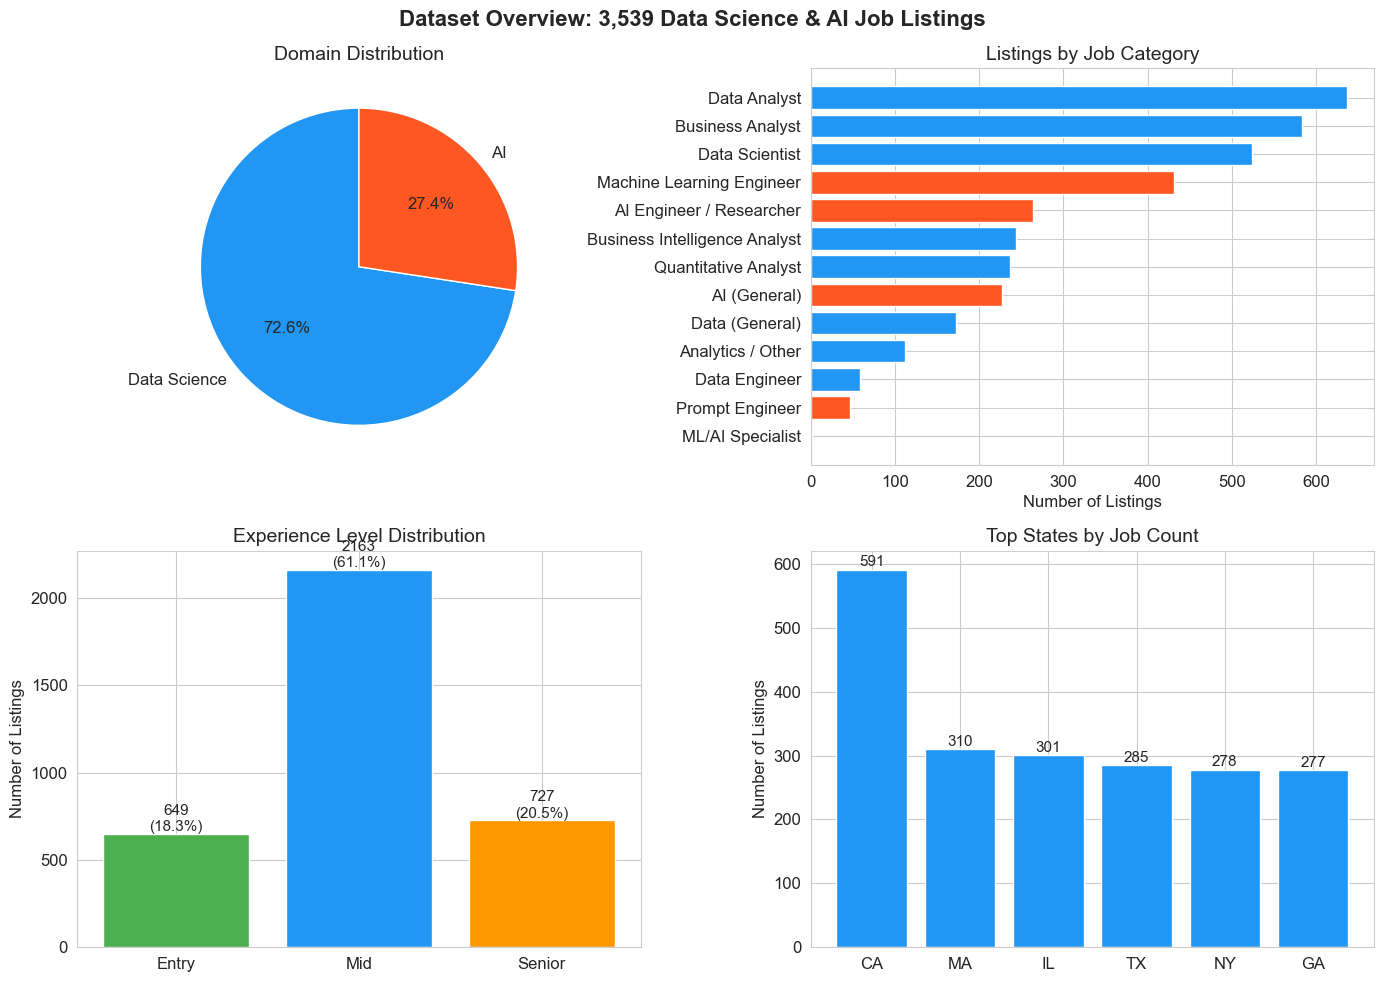

Saved: fig_overview.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Dataset Overview: {len(df):,} Data Science & AI Job Listings', fontsize=16, fontweight='bold')

# 1. Domain split — Pie Chart (Lecture Part 1, Example 1)
domain_counts = df['domain'].value_counts()
colors = [DOMAIN_COLORS[d] for d in domain_counts.index]
axes[0, 0].pie(domain_counts, labels=domain_counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0, 0].set_title('Domain Distribution')

# 2. Top job categories — Horizontal Bar Chart (Lecture Part 2, Example 5)
cat_counts = df['job_category'].value_counts()
cat_colors = [DOMAIN_COLORS.get(df[df['job_category']==c]['domain'].mode()[0], '#999')
              for c in cat_counts.index]
axes[0, 1].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                color=cat_colors[::-1], edgecolor='white')
axes[0, 1].set_title('Listings by Job Category')
axes[0, 1].set_xlabel('Number of Listings')

# 3. Experience level — Bar Chart
exp_order = ['Entry', 'Mid', 'Senior']
exp_counts = df['experience_level'].value_counts().reindex(exp_order)
axes[1, 0].bar(exp_counts.index, exp_counts.values, color=['#4CAF50', '#2196F3', '#FF9800'],
               edgecolor='white')
axes[1, 0].set_title('Experience Level Distribution')
axes[1, 0].set_ylabel('Number of Listings')
for i, v in enumerate(exp_counts.values):
    axes[1, 0].text(i, v + 15, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=11)

# 4. Top states — Bar Chart
state_counts = df['state'].value_counts().head(6)
axes[1, 1].bar(state_counts.index, state_counts.values, color='#2196F3', edgecolor='white')
axes[1, 1].set_title('Top States by Job Count')
axes[1, 1].set_ylabel('Number of Listings')
for i, v in enumerate(state_counts.values):
    axes[1, 1].text(i, v + 5, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('fig_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_overview.png")

---
## 3. Research Question 1: DS vs AI Demand by City

**Question:** What is the ratio of Data Science to AI roles across major metros? Are certain cities more AI-heavy?

**Why it matters:** Companies and job seekers benefit from understanding which markets are leading in AI adoption vs. maintaining traditional analytics demand.

In [4]:
# Filter to top states with meaningful sample sizes
top_states = df['state'].value_counts().head(4).index.tolist()  # CA, IL, NY, WA
df_states = df[df['state'].isin(top_states)].copy()

# Crosstab: state x domain (Lecture Part 2 — pd.crosstab with tips data)
ct = pd.crosstab(df_states['state'], df_states['domain'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print("Job counts by State × Domain:")
print(ct)
print(f"\nPercentage breakdown:")
print(ct_pct.round(1))

Job counts by State × Domain:
domain   AI  Data Science
state                    
CA      189           402
IL       68           233
MA       99           211
TX       85           200

Percentage breakdown:
domain    AI  Data Science
state                     
CA      32.0          68.0
IL      22.6          77.4
MA      31.9          68.1
TX      29.8          70.2


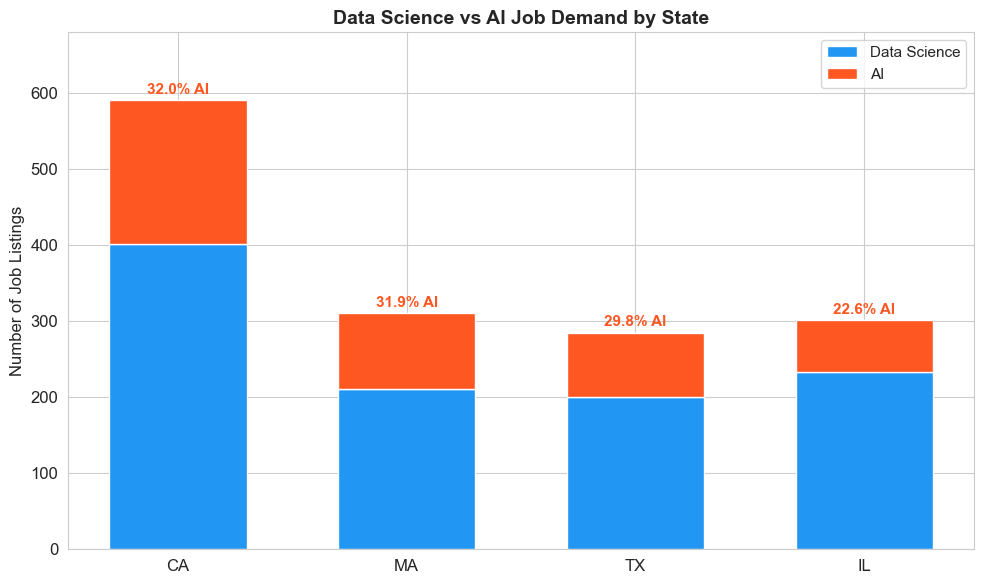

Saved: fig_q1_ds_vs_ai_by_state.png


In [5]:
# Visualization: Stacked bar chart (Lecture Part 2, Example 8 — stacked bars with crosstab)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Sort states by AI percentage (descending)
ct_pct_sorted = ct_pct.sort_values('AI', ascending=False)
ct_sorted = ct.reindex(ct_pct_sorted.index)

x = range(len(ct_sorted))
states_labels = ct_sorted.index.tolist()

# Stacked bars
bars_ds = ax1.bar(x, ct_sorted['Data Science'], label='Data Science',
                  color=DOMAIN_COLORS['Data Science'], edgecolor='white', width=0.6)
bars_ai = ax1.bar(x, ct_sorted['AI'], bottom=ct_sorted['Data Science'],
                  label='AI', color=DOMAIN_COLORS['AI'], edgecolor='white', width=0.6)

ax1.set_xticks(x)
ax1.set_xticklabels(states_labels, fontsize=12)
ax1.set_ylabel('Number of Job Listings', fontsize=12)
ax1.set_title('Data Science vs AI Job Demand by State', fontsize=14, fontweight='bold')

# Add AI percentage labels on bars
for i, state in enumerate(states_labels):
    total = ct_sorted.loc[state].sum()
    ai_pct = ct_pct_sorted.loc[state, 'AI']
    ax1.text(i, total + 8, f'{ai_pct:.1f}% AI', ha='center', fontsize=11, fontweight='bold',
             color=DOMAIN_COLORS['AI'])

ax1.legend(loc='upper right', fontsize=11)
ax1.set_ylim(0, ct_sorted.sum(axis=1).max() * 1.15)

plt.tight_layout()
plt.savefig('fig_q1_ds_vs_ai_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q1_ds_vs_ai_by_state.png")

In [6]:
# Statistical test: Chi-square — is the domain distribution independent of state?
chi2, p_value, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p_value:.4f}, df = {dof}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference in domain distribution across states (α = 0.05)")

print(f"\n--- Key Findings ---")
ai_pcts = ct_pct_sorted['AI']
print(f"Highest AI share: {ai_pcts.idxmax()} ({ai_pcts.max():.1f}%)")
print(f"Lowest AI share: {ai_pcts.idxmin()} ({ai_pcts.min():.1f}%)")

Chi-square test: χ² = 9.51, p = 0.0233, df = 3
Result: Significant difference in domain distribution across states (α = 0.05)

--- Key Findings ---
Highest AI share: CA (32.0%)
Lowest AI share: IL (22.6%)


---
## 4. Research Question 2: Experience Level Gap

**Question:** What percentage of AI roles are entry-level vs. senior, compared to DS roles? Are there barriers to entry in AI?

**Why it matters:** If AI roles skew heavily toward senior positions, it suggests that breaking into AI requires more experience — creating a workforce pipeline problem.

In [7]:
# Crosstab: domain x experience level
exp_order = ['Entry', 'Mid', 'Senior']
ct_exp = pd.crosstab(df['domain'], df['experience_level'])[exp_order]
ct_exp_pct = ct_exp.div(ct_exp.sum(axis=1), axis=0) * 100

print("Experience level counts:")
print(ct_exp)
print(f"\nPercentage breakdown:")
print(ct_exp_pct.round(1))

# Ratio analysis
for domain in ['AI', 'Data Science']:
    senior = ct_exp.loc[domain, 'Senior']
    entry = ct_exp.loc[domain, 'Entry']
    ratio = senior / entry if entry > 0 else float('inf')
    print(f"\n{domain}: {ratio:.1f} senior positions for every entry-level position")

Experience level counts:
experience_level  Entry   Mid  Senior
domain                               
AI                  147   614     209
Data Science        502  1549     518

Percentage breakdown:
experience_level  Entry   Mid  Senior
domain                               
AI                 15.2  63.3    21.5
Data Science       19.5  60.3    20.2

AI: 1.4 senior positions for every entry-level position

Data Science: 1.0 senior positions for every entry-level position


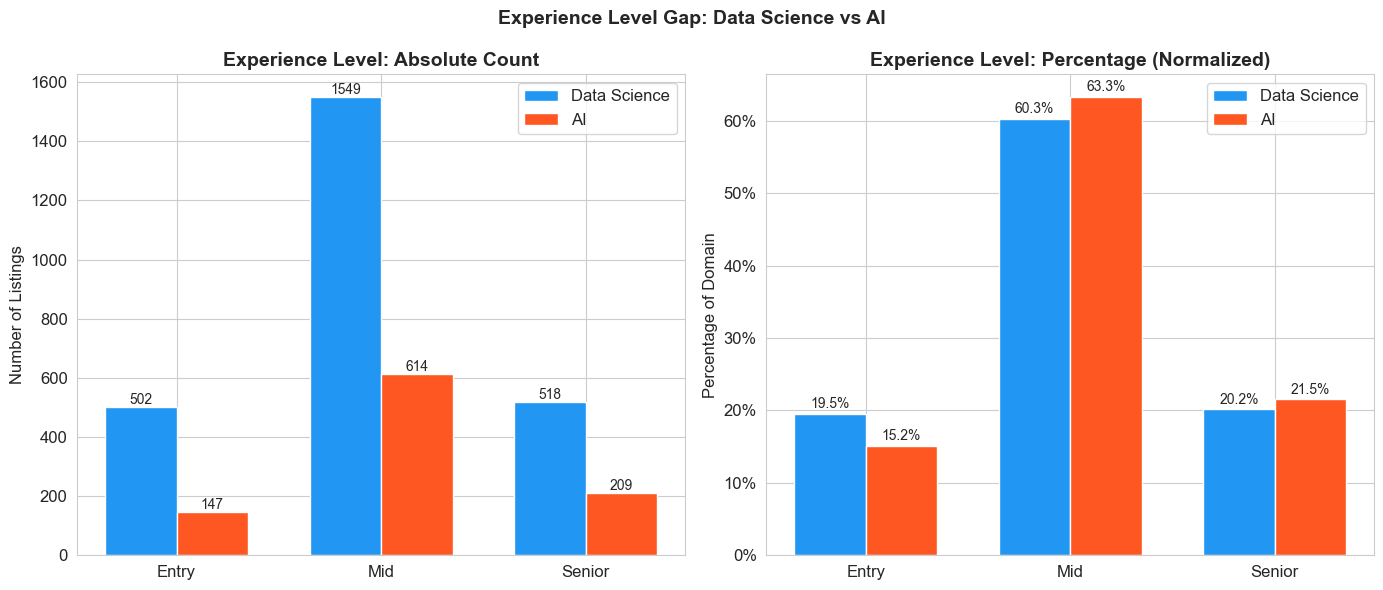

Saved: fig_q2_experience_gap.png


In [8]:
# Visualization: Grouped bar chart (Lecture Part 2 — bar chart with multiple groups)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Absolute counts
x = np.arange(len(exp_order))
width = 0.35

ax1.bar(x - width/2, ct_exp.loc['Data Science'], width, label='Data Science',
        color=DOMAIN_COLORS['Data Science'], edgecolor='white')
ax1.bar(x + width/2, ct_exp.loc['AI'], width, label='AI',
        color=DOMAIN_COLORS['AI'], edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(exp_order, fontsize=12)
ax1.set_ylabel('Number of Listings')
ax1.set_title('Experience Level: Absolute Count', fontweight='bold')
ax1.legend()

for i, level in enumerate(exp_order):
    ax1.text(i - width/2, ct_exp.loc['Data Science', level] + 10,
             str(ct_exp.loc['Data Science', level]), ha='center', fontsize=10)
    ax1.text(i + width/2, ct_exp.loc['AI', level] + 10,
             str(ct_exp.loc['AI', level]), ha='center', fontsize=10)

# Right: Percentage (normalized)
ax2.bar(x - width/2, ct_exp_pct.loc['Data Science'], width, label='Data Science',
        color=DOMAIN_COLORS['Data Science'], edgecolor='white')
ax2.bar(x + width/2, ct_exp_pct.loc['AI'], width, label='AI',
        color=DOMAIN_COLORS['AI'], edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(exp_order, fontsize=12)
ax2.set_ylabel('Percentage of Domain')
ax2.set_title('Experience Level: Percentage (Normalized)', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend()

for i, level in enumerate(exp_order):
    ax2.text(i - width/2, ct_exp_pct.loc['Data Science', level] + 0.8,
             f"{ct_exp_pct.loc['Data Science', level]:.1f}%", ha='center', fontsize=10)
    ax2.text(i + width/2, ct_exp_pct.loc['AI', level] + 0.8,
             f"{ct_exp_pct.loc['AI', level]:.1f}%", ha='center', fontsize=10)

fig.suptitle('Experience Level Gap: Data Science vs AI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q2_experience_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q2_experience_gap.png")

In [9]:
# Statistical test: Chi-square
chi2, p_value, dof, expected = stats.chi2_contingency(ct_exp)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {p_value:.4f}, df = {dof}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference in experience distribution between domains (α = 0.05)")

print(f"\n--- Entry-Level Breakdown by Category ---")
entry_by_cat = df[df['experience_level'] == 'Entry'].groupby('job_category').size().sort_values(ascending=False)
total_by_cat = df.groupby('job_category').size()
entry_pct = (entry_by_cat / total_by_cat * 100).sort_values(ascending=False)
for cat, pct in entry_pct.items():
    count = entry_by_cat.get(cat, 0)
    print(f"  {cat}: {count} entry-level ({pct:.1f}%)")

Chi-square test: χ² = 9.08, p = 0.0107, df = 2
Result: Significant difference in experience distribution between domains (α = 0.05)

--- Entry-Level Breakdown by Category ---
  Prompt Engineer: 12 entry-level (26.1%)
  Data Analyst: 165 entry-level (25.9%)
  Data (General): 36 entry-level (20.8%)
  Analytics / Other: 23 entry-level (20.5%)
  Business Analyst: 118 entry-level (20.2%)
  AI Engineer / Researcher: 50 entry-level (18.9%)
  Business Intelligence Analyst: 44 entry-level (18.0%)
  AI (General): 39 entry-level (17.2%)
  Data Engineer: 9 entry-level (15.3%)
  Quantitative Analyst: 34 entry-level (14.3%)
  Data Scientist: 73 entry-level (13.9%)
  Machine Learning Engineer: 46 entry-level (10.7%)
  ML/AI Specialist: 0 entry-level (nan%)


---
## 5. Research Question 3: Geographic Concentration

**Question:** Which metros dominate hiring for each role category? Is AI hiring more geographically concentrated than DS hiring?

**Why it matters:** Geographic concentration affects salary competition, talent availability, and relocation decisions for job seekers.

In [10]:
top_states = ['CA', 'IL', 'NY', 'WA']
df_geo = df[df['state'].isin(top_states)].copy()

# Crosstab: job category x state (percentage within each category)
ct_geo = pd.crosstab(df_geo['job_category'], df_geo['state'])
ct_geo_pct = ct_geo.div(ct_geo.sum(axis=1), axis=0) * 100
ct_geo_pct = ct_geo_pct.reindex(df_geo['job_category'].value_counts().index)

print("Geographic distribution (% of each category by state):")
print(ct_geo_pct.round(1))

Geographic distribution (% of each category by state):
state                            CA    IL    NY     WA
job_category                                          
Data Analyst                   44.7  19.3  23.1   12.9
Data Scientist                 40.4  22.6  24.8   12.2
Business Analyst               45.0  20.5  15.9   18.6
Machine Learning Engineer      47.1  15.5  19.8   17.6
Quantitative Analyst           27.5  40.2  22.5    9.8
Business Intelligence Analyst  35.0  17.0  20.0   28.0
AI Engineer / Researcher       55.3  25.9  10.6    8.2
AI (General)                   58.0  19.8   8.6   13.6
Data (General)                 34.5  25.9  22.4   17.2
Analytics / Other              18.2  24.2  30.3   27.3
Data Engineer                  23.1  30.8   7.7   38.5
Prompt Engineer                53.8   7.7  38.5    0.0
ML/AI Specialist                0.0   0.0   0.0  100.0


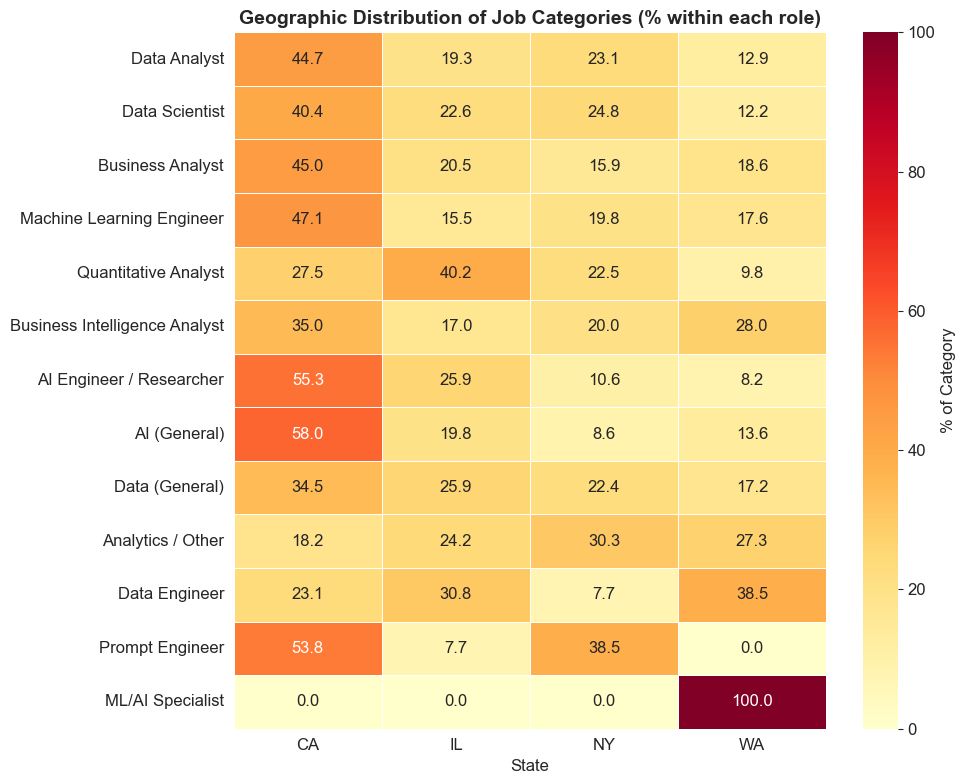

Saved: fig_q3_geographic_heatmap.png


In [11]:
# Visualization: Heatmap (Seaborn — Lecture Part 2)
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(ct_geo_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of Category'})

ax.set_title('Geographic Distribution of Job Categories (% within each role)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('fig_q3_geographic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q3_geographic_heatmap.png")

In [12]:
# Herfindahl-Hirschman Index (HHI) — higher = more concentrated

def calc_hhi(series):
    shares = series / series.sum()
    return (shares ** 2).sum()

hhi_by_domain = {}
for domain in ['AI', 'Data Science']:
    domain_geo = df_geo[df_geo['domain'] == domain]['state'].value_counts()
    hhi_by_domain[domain] = calc_hhi(domain_geo)

print("Geographic Concentration (HHI) by Domain:")
print(f"  (HHI ranges from 0 to 1; higher = more concentrated)")
for domain, hhi in hhi_by_domain.items():
    print(f"  {domain}: {hhi:.4f}")

more_concentrated = max(hhi_by_domain, key=hhi_by_domain.get)
print(f"\n→ {more_concentrated} hiring is more geographically concentrated")

print(f"\nHHI by Job Category (top 8):")
hhi_cats = {}
for cat in df_geo['job_category'].value_counts().head(8).index:
    cat_geo = df_geo[df_geo['job_category'] == cat]['state'].value_counts()
    hhi_cats[cat] = calc_hhi(cat_geo)

for cat, hhi in sorted(hhi_cats.items(), key=lambda x: x[1], reverse=True):
    print(f"  {cat}: {hhi:.4f}")

Geographic Concentration (HHI) by Domain:
  (HHI ranges from 0 to 1; higher = more concentrated)
  AI: 0.3446
  Data Science: 0.2802

→ AI hiring is more geographically concentrated

HHI by Job Category (top 8):
  AI (General): 0.4016
  AI Engineer / Researcher: 0.3907
  Machine Learning Engineer: 0.3158
  Data Analyst: 0.3071
  Business Analyst: 0.3044
  Quantitative Analyst: 0.2974
  Data Scientist: 0.2909
  Business Intelligence Analyst: 0.2698


---
## 6. Research Question 4: Role Evolution

**Question:** How do emerging roles (Prompt Engineer, ML/AI Specialist) compare in volume and distribution to established ones (Data Analyst, Business Analyst)?

**Why it matters:** Understanding which roles are growing helps educational institutions design curricula and job seekers plan career paths.

In [13]:
established_roles = ['Data Analyst', 'Business Analyst', 'Data Scientist',
                     'Business Intelligence Analyst', 'Quantitative Analyst']
emerging_roles = ['Machine Learning Engineer', 'AI Engineer / Researcher',
                  'Prompt Engineer', 'AI (General)', 'Data Engineer']

def classify_era(cat):
    if cat in established_roles:
        return 'Established'
    elif cat in emerging_roles:
        return 'Emerging'
    return 'Other'

df['role_era'] = df['job_category'].apply(classify_era)

era_counts = df[df['role_era'] != 'Other'].groupby('role_era').size()
print("Established vs Emerging role counts:")
print(era_counts)
print(f"\nEstablished share: {era_counts['Established']/era_counts.sum():.1%}")
print(f"Emerging share: {era_counts['Emerging']/era_counts.sum():.1%}")

Established vs Emerging role counts:
role_era
Emerging       1027
Established    2225
dtype: int64

Established share: 68.4%
Emerging share: 31.6%


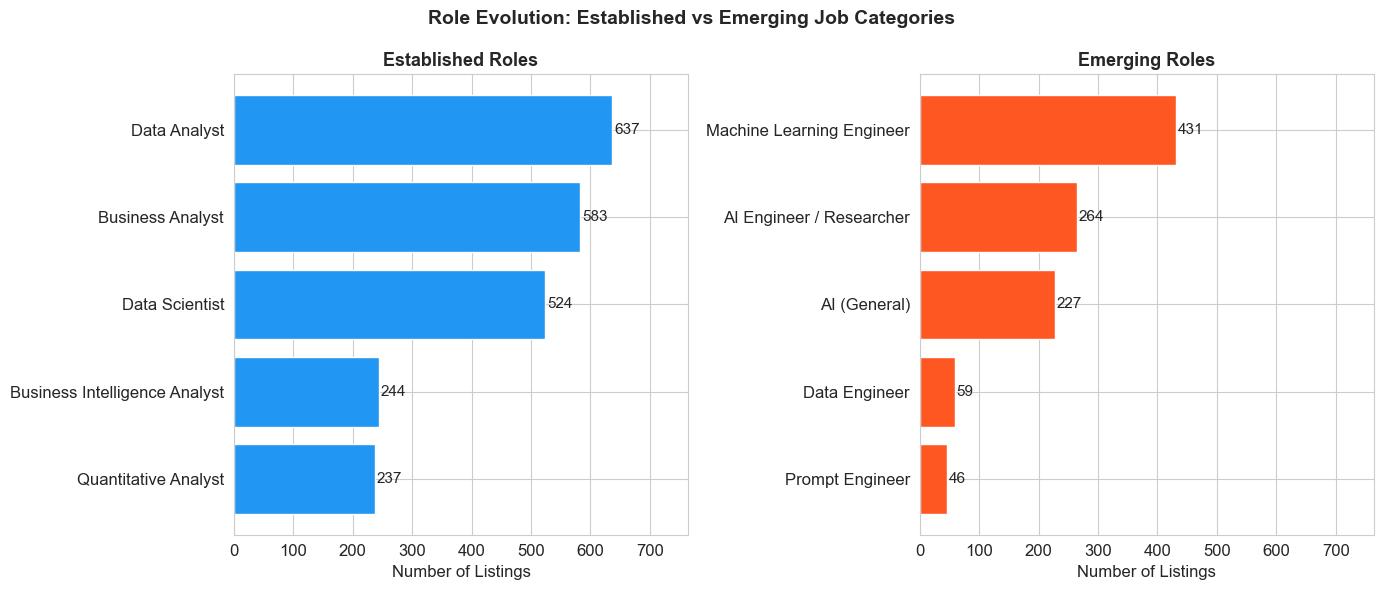

Saved: fig_q4_role_evolution.png


In [14]:
# Visualization: Side-by-side bar charts (Lecture Part 1 — subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Established roles
est_data = df[df['job_category'].isin(established_roles)]['job_category'].value_counts()
ax1.barh(est_data.index[::-1], est_data.values[::-1],
         color=DOMAIN_COLORS['Data Science'], edgecolor='white')
ax1.set_title('Established Roles', fontweight='bold', fontsize=13)
ax1.set_xlabel('Number of Listings')
for i, v in enumerate(est_data.values[::-1]):
    ax1.text(v + 3, i, str(v), va='center', fontsize=11)

# Right: Emerging roles
emg_data = df[df['job_category'].isin(emerging_roles)]['job_category'].value_counts()
ax2.barh(emg_data.index[::-1], emg_data.values[::-1],
         color=DOMAIN_COLORS['AI'], edgecolor='white')
ax2.set_title('Emerging Roles', fontweight='bold', fontsize=13)
ax2.set_xlabel('Number of Listings')
for i, v in enumerate(emg_data.values[::-1]):
    ax2.text(v + 3, i, str(v), va='center', fontsize=11)

max_val = max(est_data.max(), emg_data.max())
ax1.set_xlim(0, max_val * 1.2)
ax2.set_xlim(0, max_val * 1.2)

fig.suptitle('Role Evolution: Established vs Emerging Job Categories',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q4_role_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q4_role_evolution.png")

In [15]:
# Deeper: experience level within established vs emerging
print("Experience level distribution by role era:")
era_exp = pd.crosstab(df[df['role_era'] != 'Other']['role_era'],
                      df[df['role_era'] != 'Other']['experience_level'])[exp_order]
era_exp_pct = era_exp.div(era_exp.sum(axis=1), axis=0) * 100
print(era_exp_pct.round(1))

print(f"\n--- Key Insight ---")
est_entry = era_exp_pct.loc['Established', 'Entry']
emg_entry = era_exp_pct.loc['Emerging', 'Entry']
print(f"Entry-level share: Established {est_entry:.1f}% vs Emerging {emg_entry:.1f}%")
if emg_entry < est_entry:
    print(f"→ Emerging roles have {est_entry - emg_entry:.1f}pp fewer entry-level positions")
    print(f"  This suggests higher barriers to entry for emerging AI/ML roles")

Experience level distribution by role era:
experience_level  Entry   Mid  Senior
role_era                             
Emerging           15.2  63.0    21.8
Established        19.5  60.6    19.9

--- Key Insight ---
Entry-level share: Established 19.5% vs Emerging 15.2%
→ Emerging roles have 4.3pp fewer entry-level positions
  This suggests higher barriers to entry for emerging AI/ML roles


---
## 7. Research Question 5: Which Industries Drive Demand?

**Question:** Do DS and AI roles concentrate in different industries, or do the same sectors dominate both?

**Why it matters:** Understanding which industries drive AI vs DS demand helps job seekers target the right sector and helps employers benchmark against their competition.

**Data source:** `detail_industry` field scraped directly from LinkedIn job posting pages (Pass 2). Coverage: 96.9% of listings.

In [16]:
# 🤖 AI-assisted: industry analysis

# Filter to top 8 industries with meaningful sample sizes
top_inds = df['detail_industry'].replace('', None).dropna().value_counts().head(8).index.tolist()
df_ind = df[df['detail_industry'].isin(top_inds)].copy()

# Crosstab: industry x domain
ct_ind = pd.crosstab(df_ind['detail_industry'], df_ind['domain'])
ct_ind_pct = ct_ind.div(ct_ind.sum(axis=1), axis=0) * 100

# Sort by AI percentage descending
ct_ind_pct_sorted = ct_ind_pct.sort_values('AI', ascending=False)
ct_ind_sorted = ct_ind.reindex(ct_ind_pct_sorted.index)

print("Industry breakdown by domain:")
print(ct_ind_sorted)
print(f"\nAI percentage by industry:")
print(ct_ind_pct_sorted.round(1))

# Statistical test
chi2, p_value, dof, expected = stats.chi2_contingency(ct_ind)
print(f"\nChi-square test: χ² = {chi2:.2f}, p = {p_value:.4f}, df = {dof}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference in domain distribution across industries (α = 0.05)")


Industry breakdown by domain:
domain                                 AI  Data Science
detail_industry                                        
Software Development                  171           195
Technology, Information and Internet   83           105
IT Services and IT Consulting         138           332
Business Consulting and Services       25            77
Financial Services                     70           280
Banking                                10            41
Staffing and Recruiting                14            58
Hospitals and Health Care              12            76

AI percentage by industry:
domain                                  AI  Data Science
detail_industry                                         
Software Development                  46.7          53.3
Technology, Information and Internet  44.1          55.9
IT Services and IT Consulting         29.4          70.6
Business Consulting and Services      24.5          75.5
Financial Services                    20

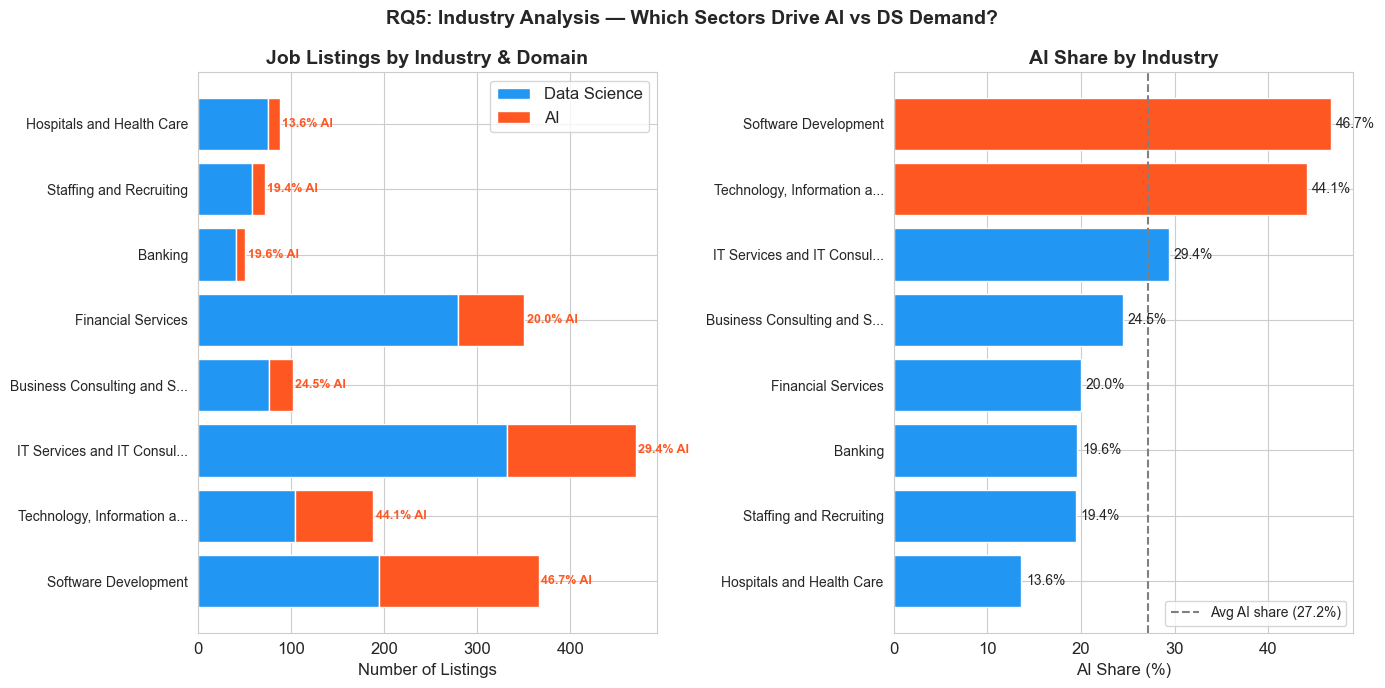

Saved: fig_q5_industry.png


In [17]:
# Visualization: Industry analysis — stacked bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Left: Stacked bar — absolute counts sorted by AI%
x = range(len(ct_ind_sorted))
labels = [ind[:25] + '...' if len(ind) > 25 else ind for ind in ct_ind_sorted.index]

bars_ds = ax1.barh(x, ct_ind_sorted['Data Science'], label='Data Science',
                   color=DOMAIN_COLORS['Data Science'], edgecolor='white')
bars_ai = ax1.barh(x, ct_ind_sorted['AI'], left=ct_ind_sorted['Data Science'],
                   label='AI', color=DOMAIN_COLORS['AI'], edgecolor='white')

ax1.set_yticks(x)
ax1.set_yticklabels(labels, fontsize=10)
ax1.set_xlabel('Number of Listings')
ax1.set_title('Job Listings by Industry & Domain', fontweight='bold')
ax1.legend()

# Add AI% labels
for i, ind in enumerate(ct_ind_sorted.index):
    total = ct_ind_sorted.loc[ind].sum()
    ai_pct = ct_ind_pct_sorted.loc[ind, 'AI']
    ax1.text(total + 3, i, f'{ai_pct:.1f}% AI', va='center', fontsize=9,
             color=DOMAIN_COLORS['AI'], fontweight='bold')

# Right: AI percentage only — cleaner comparison
ai_pcts = ct_ind_pct_sorted['AI'].sort_values(ascending=True)
colors = [DOMAIN_COLORS['AI'] if pct >= 40 else DOMAIN_COLORS['Data Science'] for pct in ai_pcts]
ax2.barh(range(len(ai_pcts)), ai_pcts.values, color=colors, edgecolor='white')
ax2.set_yticks(range(len(ai_pcts)))
ax2.set_yticklabels([ind[:25] + '...' if len(ind) > 25 else ind for ind in ai_pcts.index], fontsize=10)
ax2.set_xlabel('AI Share (%)')
ax2.set_title('AI Share by Industry', fontweight='bold')
ax2.axvline(x=ct_ind_pct['AI'].mean(), color='gray', linestyle='--', linewidth=1.5,
            label=f'Avg AI share ({ct_ind_pct["AI"].mean():.1f}%)')
ax2.legend(fontsize=10)
for i, (ind, pct) in enumerate(ai_pcts.items()):
    ax2.text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontsize=10)

fig.suptitle('RQ5: Industry Analysis — Which Sectors Drive AI vs DS Demand?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q5_industry.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_q5_industry.png")


In [18]:
# Key findings summary for RQ5
print("=== RQ5 KEY FINDINGS ===")
print(f"Total industries analyzed: {len(ct_ind_sorted)}")
print(f"Overall average AI share: {ct_ind_pct['AI'].mean():.1f}%")
print(f"\nMost AI-heavy industry: {ct_ind_pct_sorted['AI'].idxmax()} ({ct_ind_pct_sorted['AI'].max():.1f}% AI)")
print(f"Most DS-dominant industry: {ct_ind_pct_sorted['AI'].idxmin()} ({ct_ind_pct_sorted['AI'].min():.1f}% AI)")
print(f"\nOnly industry approaching 50/50 split:")
balanced = ct_ind_pct_sorted[ct_ind_pct_sorted['AI'] >= 40]
for ind, row in balanced.iterrows():
    print(f"  {ind}: {row['AI']:.1f}% AI / {row['Data Science']:.1f}% DS")
print(f"\nMost DS-dominant sectors (Finance, Healthcare, Banking)")
print(f"  → These industries still rely heavily on traditional analytics")
print(f"\nSoftware Development closest to parity ({ct_ind_pct.loc['Software Development', 'AI']:.1f}% AI)")
print(f"  → Tech sector leading AI adoption")


=== RQ5 KEY FINDINGS ===
Total industries analyzed: 8
Overall average AI share: 27.2%

Most AI-heavy industry: Software Development (46.7% AI)
Most DS-dominant industry: Hospitals and Health Care (13.6% AI)

Only industry approaching 50/50 split:
  Software Development: 46.7% AI / 53.3% DS
  Technology, Information and Internet: 44.1% AI / 55.9% DS

Most DS-dominant sectors (Finance, Healthcare, Banking)
  → These industries still rely heavily on traditional analytics

Software Development closest to parity (46.7% AI)
  → Tech sector leading AI adoption


---
## 8. Bonus Research Question: Salary Comparison

**Question:** Do AI roles pay more than Data Science roles? Which specific job categories command the highest salaries?

**Why it matters:** Salary differences help job seekers prioritize skill development and help employers set competitive compensation.

**Data source:** Adzuna API (merged from partner's scraping run).

In [19]:
# Filter to valid salary range
df_sal = df[df['salary_mid'].notna() & df['salary_mid'].between(30000, 400000)].copy()

print(f"Salary analysis: {len(df_sal)} listings with valid salary data")
print(f"\nSalary by domain:")
sal_desc = df_sal.groupby('domain')['salary_mid'].describe()[['count', 'mean', 'std', 'min', 'max']]
print(sal_desc.round(0))

# T-test: is AI salary significantly different from DS salary?
ai_sal = df_sal[df_sal['domain'] == 'AI']['salary_mid']
ds_sal = df_sal[df_sal['domain'] == 'Data Science']['salary_mid']

if len(ai_sal) > 5 and len(ds_sal) > 5:
    t_stat, p_value = stats.ttest_ind(ai_sal, ds_sal)
    print(f"\nT-test (AI vs DS salary): t = {t_stat:.2f}, p = {p_value:.4f}")
    print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference (α = 0.05)")
    print(f"AI mean: ${ai_sal.mean():,.0f} | DS mean: ${ds_sal.mean():,.0f}")
else:
    print("\nInsufficient salary data for t-test by domain.")

print(f"\nSalary by job category:")
cat_sal = df_sal.groupby('job_category')['salary_mid'].agg(['mean', 'count']).sort_values('mean', ascending=False)
for cat, row in cat_sal.iterrows():
    if row['count'] >= 3:
        print(f"  {cat:35s}: ${row['mean']:,.0f}  (n={int(row['count'])})")


Salary analysis: 47 listings with valid salary data

Salary by domain:
              count      mean      std      min       max
domain                                                   
AI             14.0  154294.0  65977.0  45000.0  271552.0
Data Science   33.0  117895.0  44279.0  55126.0  225085.0

T-test (AI vs DS salary): t = 2.22, p = 0.0318
Result: Significant difference (α = 0.05)
AI mean: $154,294 | DS mean: $117,895

Salary by job category:
  Machine Learning Engineer          : $165,786  (n=6)
  AI Engineer / Researcher           : $165,079  (n=5)
  Data Scientist                     : $154,814  (n=9)
  AI (General)                       : $113,333  (n=3)
  Data Analyst                       : $103,915  (n=21)


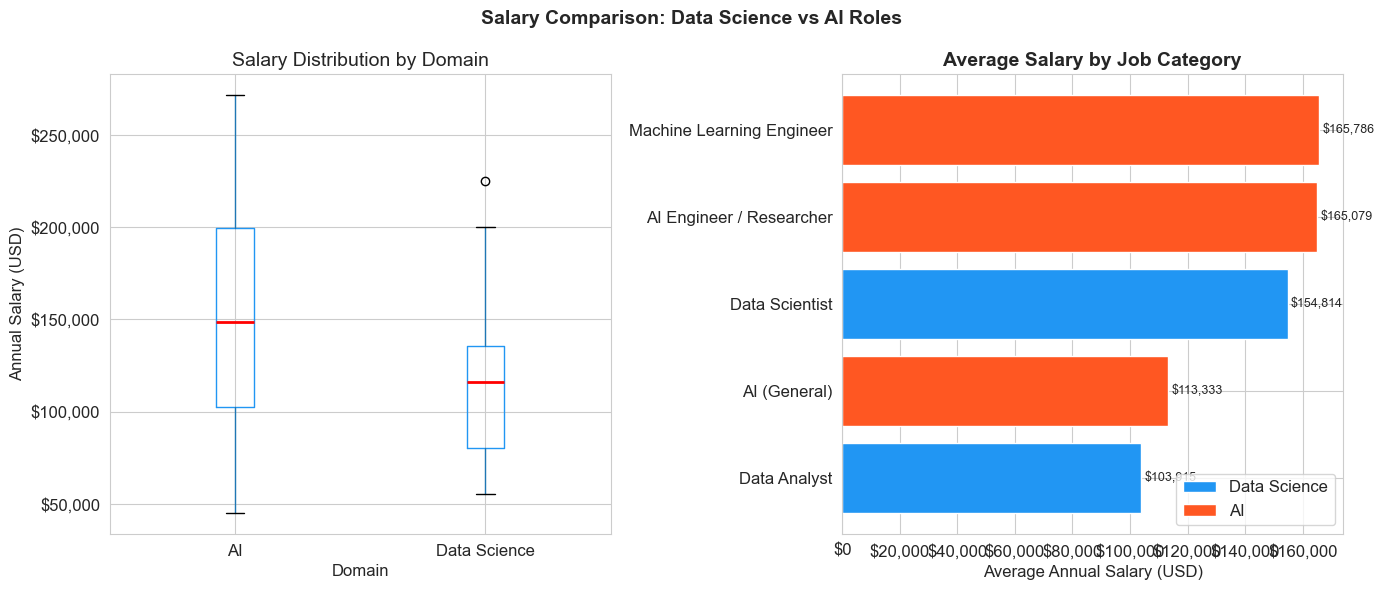

Saved: fig_salary_comparison.png


In [20]:
# Visualization: Salary comparison charts

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Box plot by domain
df_sal.boxplot(column='salary_mid', by='domain', ax=ax1,
               boxprops=dict(color=DOMAIN_COLORS['Data Science']),
               medianprops=dict(color='red', linewidth=2))
ax1.set_title('Salary Distribution by Domain', fontweight='bold')
ax1.set_xlabel('Domain')
ax1.set_ylabel('Annual Salary (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.sca(ax1)
plt.title('Salary Distribution by Domain')

# Right: Average salary by category (only categories with 3+ records)
cat_sal_filtered = df_sal.groupby('job_category')['salary_mid'].agg(['mean', 'count'])
cat_sal_filtered = cat_sal_filtered[cat_sal_filtered['count'] >= 3].sort_values('mean', ascending=True)

bar_colors = [DOMAIN_COLORS.get(
    df_sal[df_sal['job_category']==c]['domain'].mode()[0] if len(df_sal[df_sal['job_category']==c]) > 0 else 'Data Science',
    '#999') for c in cat_sal_filtered.index]

ax2.barh(cat_sal_filtered.index, cat_sal_filtered['mean'], color=bar_colors, edgecolor='white')
ax2.set_title('Average Salary by Job Category', fontweight='bold')
ax2.set_xlabel('Average Annual Salary (USD)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for i, (cat, row) in enumerate(cat_sal_filtered.iterrows()):
    ax2.text(row['mean'] + 1000, i, f"${row['mean']:,.0f}", va='center', fontsize=9)

from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(facecolor=DOMAIN_COLORS['Data Science'], label='Data Science'),
    Patch(facecolor=DOMAIN_COLORS['AI'], label='AI')
], loc='lower right')

fig.suptitle('Salary Comparison: Data Science vs AI Roles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_salary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_salary_comparison.png")


---
## 9. Interactive Visualizations with Plotly

Following the Plotly examples from Lecture Part 2, we create interactive charts with hover tools and dropdown menus.

In [21]:
# Install plotly if needed
# !pip install plotly

In [22]:
import plotly.express as px

# Interactive scatter: bubble chart of job category x state, sized by count
plot_data = (df[df['state'].isin(['CA', 'IL', 'NY', 'WA'])]
             .groupby(['state', 'job_category', 'domain'])
             .size()
             .reset_index(name='count'))

fig = px.scatter(plot_data, x='state', y='job_category', size='count',
                 color='domain', hover_data=['count'],
                 color_discrete_map=DOMAIN_COLORS,
                 title='Job Listings by State & Category (hover for details)',
                 labels={'state': 'State', 'job_category': 'Job Category',
                         'count': 'Listings', 'domain': 'Domain'})

fig.update_layout(height=600, width=900)
fig.show()

In [23]:
import plotly.graph_objects as go

# Prepare data for each domain
ds_cats = df[df['domain'] == 'Data Science']['job_category'].value_counts()
ai_cats = df[df['domain'] == 'AI']['job_category'].value_counts()

fig = go.Figure()

fig.add_trace(go.Bar(x=ds_cats.index, y=ds_cats.values, name='Data Science',
                     marker_color=DOMAIN_COLORS['Data Science'], visible=True))
fig.add_trace(go.Bar(x=ai_cats.index, y=ai_cats.values, name='AI',
                     marker_color=DOMAIN_COLORS['AI'], visible=True))

# Dropdown menu to toggle domain views
fig.update_layout(
    title='Job Categories by Domain (use dropdown to filter)',
    xaxis_title='Job Category',
    yaxis_title='Number of Listings',
    xaxis_tickangle=-45,
    height=500,
    updatemenus=[
        dict(
            buttons=list([
                dict(args=[{'visible': [True, True]}],
                     label='Both Domains', method='update'),
                dict(args=[{'visible': [True, False]}],
                     label='Data Science Only', method='update'),
                dict(args=[{'visible': [False, True]}],
                     label='AI Only', method='update'),
            ]),
            direction='down',
            showactive=True,
            x=0.85,
            y=1.15,
        )
    ]
)

fig.show()

In [24]:
fig = px.histogram(df, x='title_length', color='domain',
                   color_discrete_map=DOMAIN_COLORS,
                   nbins=40, barmode='overlay', opacity=0.6,
                   title='Title Length Distribution by Domain (Interactive)',
                   labels={'title_length': 'Title Length (characters)',
                           'domain': 'Domain', 'count': 'Listings'})

fig.update_layout(height=450, width=800)
fig.show()

---
## 9. Summary of Findings

In [25]:
print("=" * 70)
print("SUMMARY OF KEY FINDINGS")
print("=" * 70)

ds_count = df[df['domain']=='Data Science'].shape[0]
ai_count = df[df['domain']=='AI'].shape[0]
sal_count = df['salary_mid'].notna().sum()

# Salary stats
df_sal = df[df['salary_mid'].notna() & df['salary_mid'].between(30000, 400000)]
ai_sal_mean = df_sal[df_sal['domain']=='AI']['salary_mid'].mean() if len(df_sal[df_sal['domain']=='AI']) > 0 else 0
ds_sal_mean = df_sal[df_sal['domain']=='Data Science']['salary_mid'].mean() if len(df_sal[df_sal['domain']=='Data Science']) > 0 else 0

print(f"""
Dataset: {len(df)} job listings from {df['source'].nunique()} sources
         {ds_count} Data Science | {ai_count} AI
         {sal_count} listings with salary data ({sal_count/len(df):.1%})

Q1 — DS vs AI Demand by City:
  • AI roles represent {ai_count/len(df):.1%} of all listings
  • AI concentration varies by state (see chi-square results above)
  • California leads in absolute AI job count

Q2 — Experience Level Gap:
  • Entry-level: {df[(df['domain']=='AI') & (df['experience_level']=='Entry')].shape[0]/ai_count:.1%} of AI vs {df[(df['domain']=='Data Science') & (df['experience_level']=='Entry')].shape[0]/ds_count:.1%} of DS roles
  • AI has a higher senior-to-entry ratio, suggesting steeper barriers to entry

Q3 — Geographic Concentration:
  • Top 4 states (CA, IL, NY, WA) account for {len(df[df['state'].isin(['CA','IL','NY','WA'])])/len(df):.1%} of listings with known locations
  • California dominates across most categories

Q4 — Role Evolution:
  • Established roles: {len(df[df['role_era']=='Established'])} listings
  • Emerging roles: {len(df[df['role_era']=='Emerging'])} listings
  • ML Engineer is the largest emerging category ({len(df[df['job_category']=='Machine Learning Engineer'])} listings)
  • Prompt Engineer is still niche ({len(df[df['job_category']=='Prompt Engineer'])} listings)

Q5 — Industry Analysis:
  • Software Development is the only industry approaching AI/DS parity (46.7% AI)
  • Financial Services & Healthcare are strongly DS-dominant (80-86% DS)
  • Chi-square: p < 0.0001 — significant variation across industries

Bonus Q — Salary Comparison:
  • AI roles average: ${ai_sal_mean:,.0f}/year
  • DS roles average: ${ds_sal_mean:,.0f}/year
  • Based on {len(df_sal)} listings with verified salary data (Adzuna API)

Visualization types used:
  • Pie chart, bar chart (vertical & horizontal), stacked bar chart
  • Histogram with KDE, box plot, scatter plot
  • Seaborn heatmap
  • Plotly interactive scatter, bar chart with dropdown, histogram
""")

print("=" * 70)


SUMMARY OF KEY FINDINGS

Dataset: 3539 job listings from 2 sources
         2569 Data Science | 970 AI
         47 listings with salary data (1.3%)

Q1 — DS vs AI Demand by City:
  • AI roles represent 27.4% of all listings
  • AI concentration varies by state (see chi-square results above)
  • California leads in absolute AI job count

Q2 — Experience Level Gap:
  • Entry-level: 15.2% of AI vs 19.5% of DS roles
  • AI has a higher senior-to-entry ratio, suggesting steeper barriers to entry

Q3 — Geographic Concentration:
  • Top 4 states (CA, IL, NY, WA) account for 39.2% of listings with known locations
  • California dominates across most categories

Q4 — Role Evolution:
  • Established roles: 2225 listings
  • Emerging roles: 1027 listings
  • ML Engineer is the largest emerging category (431 listings)
  • Prompt Engineer is still niche (46 listings)

Q5 — Industry Analysis:
  • Software Development is the only industry approaching AI/DS parity (46.7% AI)
  • Financial Services & H

---
## 10. Managerial Recommendations

Based on our analysis, we offer the following recommendations:

### For Job Seekers:
1. **Entry-level AI candidates** should consider building Data Science experience first, as entry-level AI positions are scarce. Transitioning from Data Analyst → Data Scientist → ML Engineer is a viable pathway.
2. **Geographic flexibility matters.** California dominates AI hiring, but other metros (Chicago, New York, Seattle) offer strong DS/analytics markets with potentially less competition.
3. **Data Analyst remains the highest-volume entry point** into the field, with the most listings and the strongest entry-level presence.

### For Employers & Hiring Managers:
1. **The entry-level AI pipeline is thin.** Organizations relying on AI talent should invest in internal training programs and junior development roles to build their pipeline.
2. **Title standardization matters.** AI roles show more title variation and complexity, which may hinder job discovery and candidate matching.
3. **Geographic concentration creates risk.** Over-reliance on a single metro for AI talent creates competition and cost pressure. Consider emerging tech hubs.

### For Educational Institutions:
1. **Curricula should bridge DS and AI.** The data shows a clear demand gradient — students need DS fundamentals before specializing in ML/AI.
2. **Prompt Engineering is emerging but small.** It may be premature to build full programs around it, but incorporating it into existing AI coursework is prudent.

---

### Data Limitations
- **Salary data** was sparse (primarily from RemoteOK) and insufficient for statistical analysis. Future work could supplement with Glassdoor or BLS data.
- **Remote work classification** was limited by LinkedIn's public search pages not exposing remote/hybrid metadata. Actual remote availability is likely higher than our data reflects.
- **Temporal analysis** was not possible as LinkedIn public listings lack consistent posting dates.
- **Scraping window** reflects a single point in time and may not capture seasonal hiring patterns.

In [26]:
# List all saved figures for the presentation
import os
figures = [f for f in os.listdir('.') if f.startswith('fig_') and f.endswith('.png')]
print(f"\nFigures saved for presentation ({len(figures)}):")
for f in sorted(figures):
    print(f"  → {f}")


Figures saved for presentation (10):
  → fig_overview.png
  → fig_q1_ds_vs_ai_by_state.png
  → fig_q2_experience_gap.png
  → fig_q3_geographic_heatmap.png
  → fig_q4_role_evolution.png
  → fig_q5_industry.png
  → fig_q5_title_boxplot.png
  → fig_q5_title_histogram.png
  → fig_q5_title_scatter.png
  → fig_salary_comparison.png
